In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries loaded successfully!


In [2]:
import os
print(os.getcwd())

C:\Users\Admin\ipl_project


In [3]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'deliveries.csv', 'ipl_analysis.ipynb', 'matches.csv']


In [4]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
print("\nMatches columns:", list(matches.columns))

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)

Matches columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


C:\Users\Admin\AppData\Local\Temp\ipykernel_3272\288839861.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_teams.values, y=top_teams.index, palette="Blues_r")


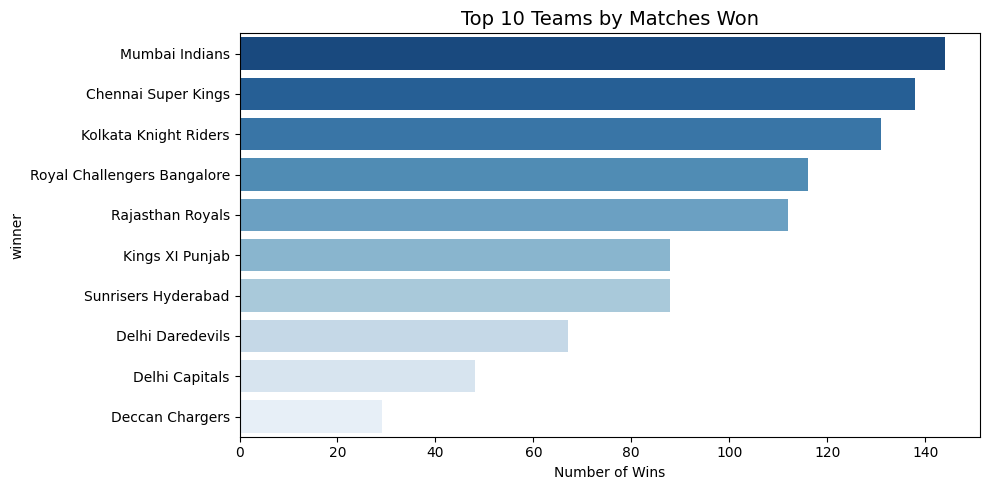

In [5]:
plt.figure(figsize=(10,5))
top_teams = matches['winner'].value_counts().head(10)
sns.barplot(x=top_teams.values, y=top_teams.index, palette="Blues_r")
plt.title("Top 10 Teams by Matches Won", fontsize=14)
plt.xlabel("Number of Wins")
plt.tight_layout()
plt.savefig("team_wins.png")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_3272\915443833.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Lost Match', 'Won Match'], y=toss_impact.values, palette="Oranges")


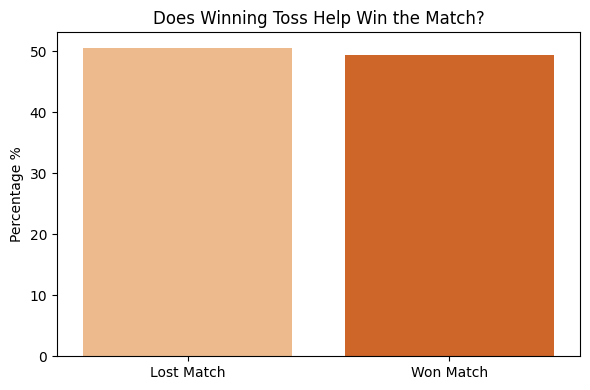

In [6]:
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']
toss_impact = matches['toss_win_match_win'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
sns.barplot(x=['Lost Match', 'Won Match'], y=toss_impact.values, palette="Oranges")
plt.title("Does Winning Toss Help Win the Match?")
plt.ylabel("Percentage %")
plt.tight_layout()
plt.savefig("toss_impact.png")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_3272\1509431002.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette="Oranges_r")


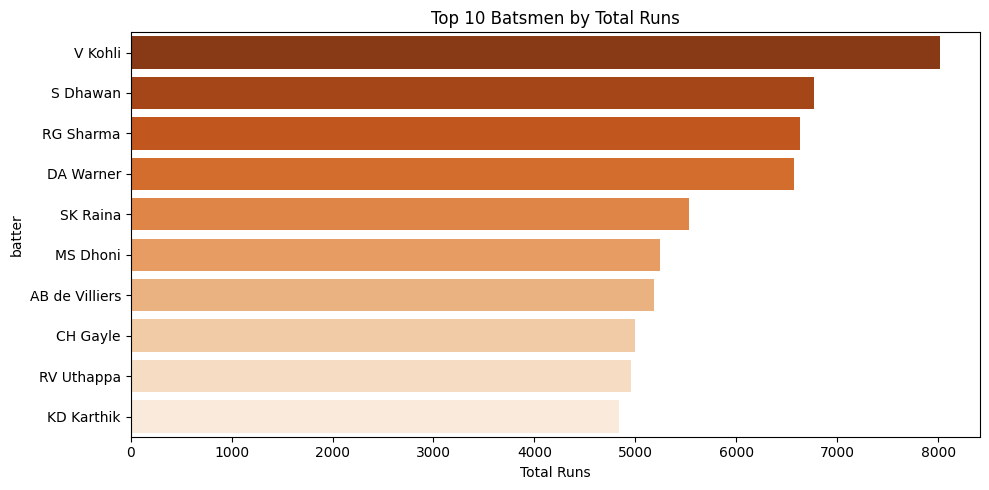

In [7]:
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette="Oranges_r")
plt.title("Top 10 Batsmen by Total Runs")
plt.xlabel("Total Runs")
plt.tight_layout()
plt.savefig("top_batsmen.png")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_3272\2236410260.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette="Greens_r")


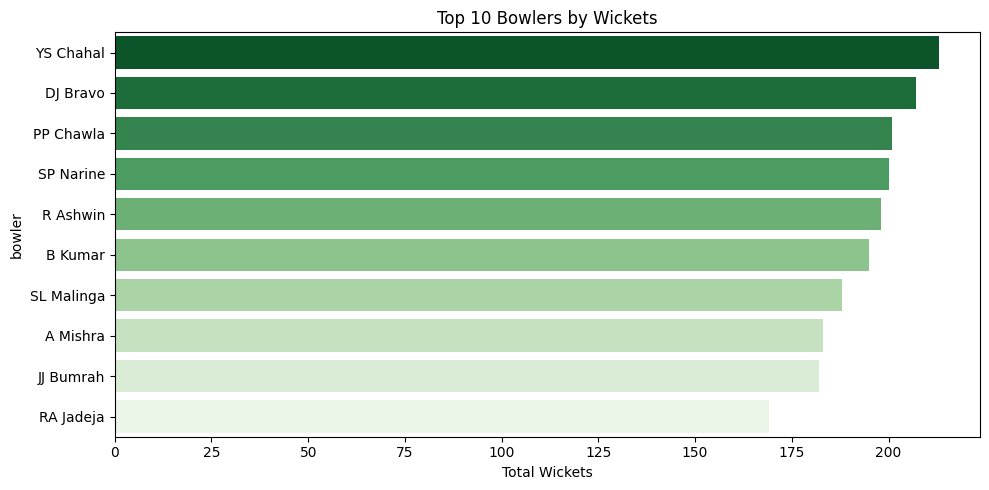

In [8]:
wickets = deliveries[deliveries['player_dismissed'].notna()]
top_bowlers = wickets.groupby('bowler')['player_dismissed'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette="Greens_r")
plt.title("Top 10 Bowlers by Wickets")
plt.xlabel("Total Wickets")
plt.tight_layout()
plt.savefig("top_bowlers.png")
plt.show()

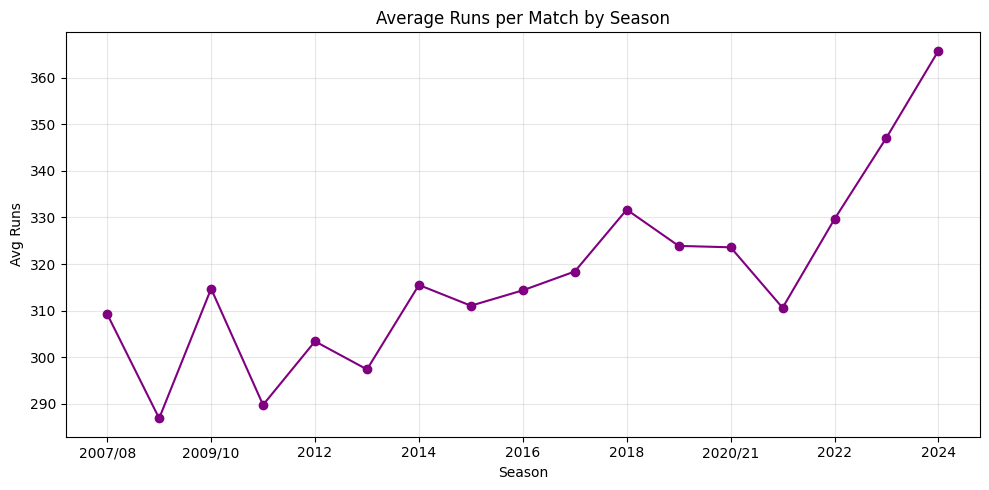

In [9]:
season_runs = deliveries.groupby('match_id')['total_runs'].sum().reset_index()
season_runs = season_runs.merge(matches[['id','season']], left_on='match_id', right_on='id')
season_avg = season_runs.groupby('season')['total_runs'].mean()

plt.figure(figsize=(10,5))
season_avg.plot(kind='line', marker='o', color='purple')
plt.title("Average Runs per Match by Season")
plt.ylabel("Avg Runs")
plt.xlabel("Season")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("season_trend.png")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_3272\281426433.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_venues.values, y=top_venues.index, palette="Reds_r")


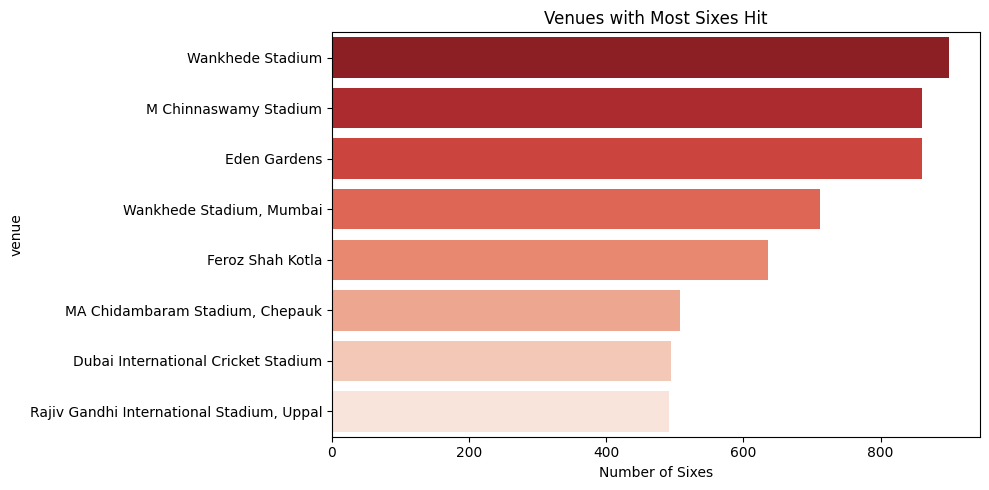

In [10]:
sixes = deliveries[deliveries['batsman_runs'] == 6]
venue_sixes = sixes.merge(matches[['id','venue']], left_on='match_id', right_on='id')
top_venues = venue_sixes['venue'].value_counts().head(8)

plt.figure(figsize=(10,5))
sns.barplot(x=top_venues.values, y=top_venues.index, palette="Reds_r")
plt.title("Venues with Most Sixes Hit")
plt.xlabel("Number of Sixes")
plt.tight_layout()
plt.savefig("venue_sixes.png")
plt.show()